In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D 
from matplotlib import gridspec

import os

import seaborn as sns


In [2]:
## Downloaded CR-arc count matrix results
data_dir = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/downloaded_counts/VIB_10xmultiome_2'



## Entropy filtered atac
entropy_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000F'


union_cell_subdir = os.path.join(entropy_dir, '_cell_calling_comparison')
FRIPpeaks_vs_Rawpeaks_dir = os.path.join(union_cell_subdir, 'FRIPpeaks_vs_Rawpeaks')


# Load peak annotations [including peak AUC score from Genrich peaks]
annotation_dir = os.path.join(FRIPpeaks_vs_Rawpeaks_dir, 'annotation')
lost_peaks_annot = pd.read_csv(os.path.join(annotation_dir, 'annotated_lost_peaks.bed'), sep='\t')
newly_discovered_peaks_annot = pd.read_csv(os.path.join(annotation_dir, 'annotated_newly_discovered_peaks.bed'),  sep='\t')

FRIPpeaks_dir = os.path.join(union_cell_subdir, 'FRIP_cells_peaks/')
Rawpeaks_dir = os.path.join(union_cell_subdir, 'Rawpeaks/')
frip_peaks_annot_file = os.path.join(FRIPpeaks_dir, 'annotation', 'annotated_peaks.bed')
raw_peaks_annot_file = os.path.join(Rawpeaks_dir, 'annotation', 'annotated_peaks.bed')
frip_peaks_annot = pd.read_csv(frip_peaks_annot_file, sep='\t')
raw_peaks_annot = pd.read_csv(raw_peaks_annot_file, sep='\t')


In [3]:

## calcualte peak size
newly_discovered_peaks_annot['peak_size'] = newly_discovered_peaks_annot['End'] - newly_discovered_peaks_annot['Start']
lost_peaks_annot['peak_size'] = lost_peaks_annot['End'] - lost_peaks_annot['Start']

raw_peaks_annot['peak_size'] = raw_peaks_annot['End'] - raw_peaks_annot['Start']
frip_peaks_annot['peak_size'] = frip_peaks_annot['End'] - frip_peaks_annot['Start']

## Peak AUC score 

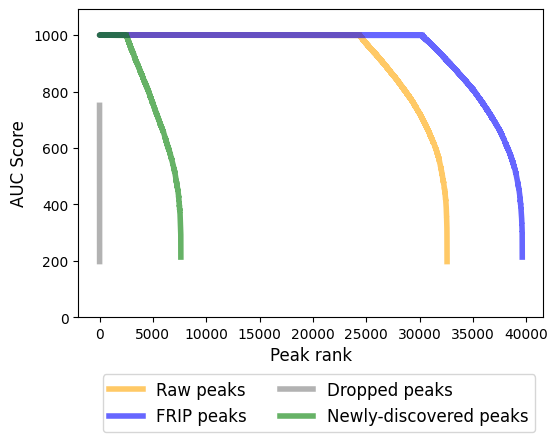

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(raw_peaks_annot['Peak Score'].sort_values(ascending=False), '-', color='orange', alpha=0.6, label='Raw peaks', lw=4)
ax.plot(frip_peaks_annot['Peak Score'].sort_values(ascending=False), '-', color='blue', alpha=0.6, label='FRIP peaks', lw=4)
ax.plot(lost_peaks_annot['Peak Score'].sort_values(ascending=False), '-', color='gray', alpha=0.6, label='Dropped peaks', lw=4)
ax.plot(newly_discovered_peaks_annot['Peak Score'].sort_values(ascending=False), '-', color='green', alpha=0.6, label='Newly-discovered peaks', lw=4)
# ax.set_title('Peak Score Comparison', fontsize=12)
ax.set_xlabel('Peak rank', fontsize=12)
ax.set_ylabel('AUC Score', fontsize=12)
ax.set_ylim(0, ax.get_ylim()[1]*1.05)
ax.legend( loc='lower right', bbox_to_anchor=(1, -0.4), fontsize=12, ncol=2)

--- 	 Raw
peaks , FRIP
Peaks , Dropped
Peaks Newly-discovered
Peaks
Mean [np.float64(945.7244872896966), np.float64(948.0975265017668), np.float64(470.57142857142856), np.float64(822.5961689845185)]
Median [np.float64(1000.0), np.float64(1000.0), np.float64(438.0), np.float64(872.0)]


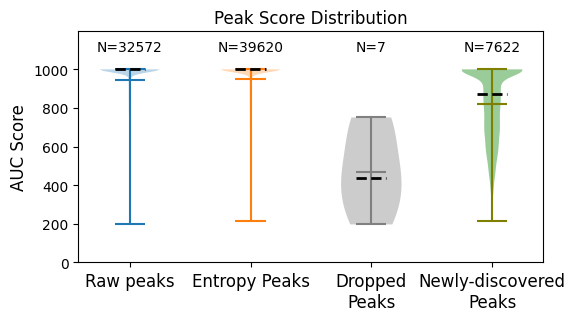

In [5]:
fig, ax = plt.subplots(figsize=(6, 3))
x_positions = range(4)
width = 0.5 




v1 = ax.violinplot( raw_peaks_annot['Peak Score'], positions=[0], widths=width, vert=True, showmedians=True, showmeans=True,)
v2 = ax.violinplot( frip_peaks_annot['Peak Score'], positions=[1], widths=width, vert=True, showmedians=True, showmeans=True,)
v3 = ax.violinplot( lost_peaks_annot['Peak Score'], positions=[2], widths=width, vert=True, showmedians=True, showmeans=True,)
v4 = ax.violinplot( newly_discovered_peaks_annot['Peak Score'], positions=[3], widths=width, vert=True, showmedians=True, showmeans=True,)


ax.text(0, ax.get_ylim()[1]*1.05, f'N={len(raw_peaks_annot)}', ha='center', fontsize=10)
ax.text(1, ax.get_ylim()[1]*1.05, f'N={len(frip_peaks_annot)}', ha='center', fontsize=10)
ax.text(2, ax.get_ylim()[1]*1.05, f'N={len(lost_peaks_annot)}', ha='center', fontsize=10)
ax.text(3, ax.get_ylim()[1]*1.05, f'N={len(newly_discovered_peaks_annot)}', ha='center', fontsize=10)


ax.set_ylim(0, ax.get_ylim()[1]*1.15)
ax.set_xticks(x_positions, [ 'Raw peaks', 'Entropy Peaks', 'Dropped\nPeaks', 'Newly-discovered\nPeaks', ], fontsize=12)  
ax.set_ylabel('AUC Score', fontsize=12)
ax.set_title('Peak Score Distribution', fontsize=12)


for body in v3['bodies']:
    body.set_alpha(0.4)
    body.set_facecolor('grey')

for partname in ['cbars', 'cmins', 'cmaxes', 'cmeans']:
    v3[partname].set_edgecolor('grey')

for body in v4['bodies']:
    body.set_alpha(0.4)
    body.set_facecolor('green')
    
for partname in ['cbars', 'cmins', 'cmaxes', 'cmeans']:
    v4[partname].set_edgecolor('olive')

for v in [v1, v2, v3, v4]:
    v['cmedians'].set_linewidth(2)
    v['cmedians'].set_linestyle('--')
    v['cmedians'].set_color('black')




auc_score = [
             raw_peaks_annot['Peak Score'], 
             frip_peaks_annot['Peak Score'], 
             lost_peaks_annot['Peak Score'], 
             newly_discovered_peaks_annot['Peak Score'], 
             ]
mean_score = [np.mean(a) for a in auc_score]
median_score = [np.median(a) for a in auc_score]
print ('--- \t Raw\npeaks , FRIP\nPeaks , Dropped\nPeaks', 'Newly-discovered\nPeaks')
print (f'Mean {mean_score}')
print (f'Median {median_score}')


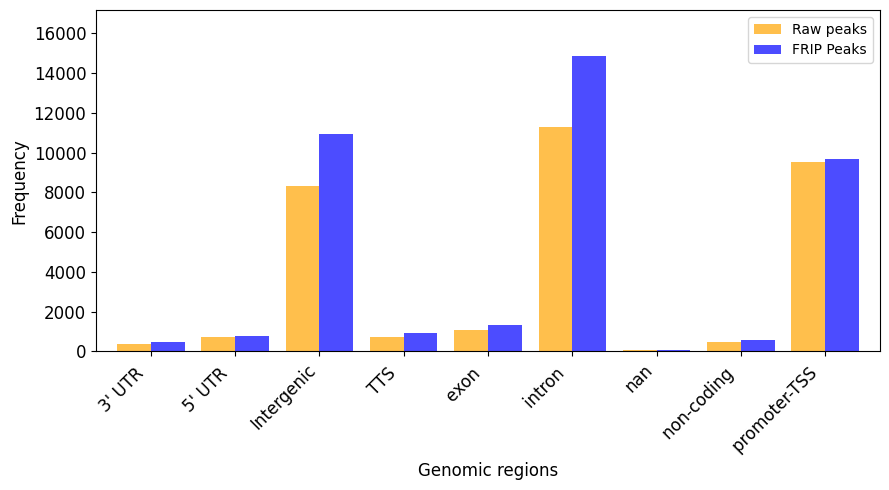

In [6]:
def simplify_annotation(annot_df, inplace=False):
    """
    Simplify the Annotation column.
    """
    if not inplace:
        annot_df = annot_df.copy()
        annot_df['simple_annotation'] = annot_df['Annotation'].apply(lambda x: str(x).split('(')[0])  
        return annot_df
    else:
        # in place change of the  DataFrame
        annot_df['simple_annotation'] = annot_df['Annotation'].apply(lambda x: str(x).split('(')[0])  
        
simplify_annotation(raw_peaks_annot, inplace=True)
simplify_annotation(frip_peaks_annot, inplace=True)
simplify_annotation(lost_peaks_annot, inplace=True)
simplify_annotation(newly_discovered_peaks_annot, inplace=True)

        
standard_peak_freq = raw_peaks_annot['simple_annotation'].value_counts()
frip_peak_freq = frip_peaks_annot['simple_annotation'].value_counts()
newly_discovered_peak_freq = newly_discovered_peaks_annot['simple_annotation'].value_counts()
lost_standard_peak_freq = lost_peaks_annot['simple_annotation'].value_counts()

freq_df = pd.DataFrame({
    'Raw peaks': standard_peak_freq,
    'FRIP Peaks': frip_peak_freq
}).fillna(0)

fig, ax = plt.subplots(figsize=(9, 5))
freq_df.plot(kind='bar', width=0.8, alpha=0.7, ax=ax, color=['orange', 'blue'], fontsize=12)



# ax.set_title('Peak Annotation Frequency Comparison', fontsize=12)
ax.set_ylim( 0, ax.get_ylim()[1]*1.1)
ax.set_xlabel('Genomic regions', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylabel('Frequency', fontsize=12)
ax.legend()
fig.tight_layout()

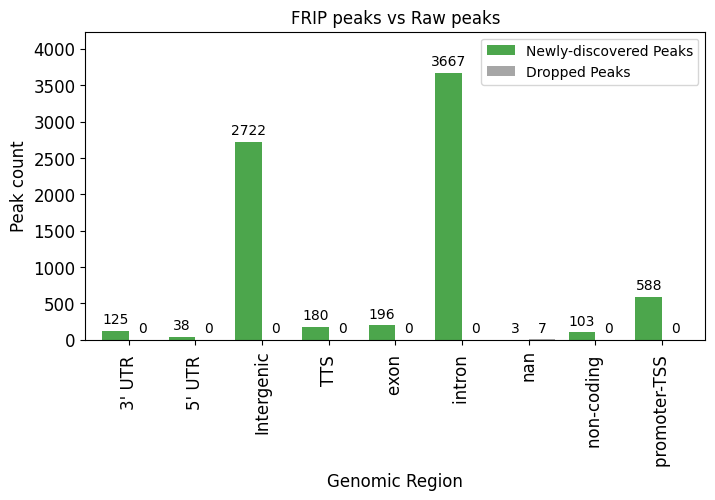

In [7]:
color_map = {'intron ': 'blue', 'promoter-TSS ': 'orange', 'Intergenic': 'green', 'exon ': 'red',
                "5' UTR ": 'purple', 'TTS ': 'brown', 'non-coding ': 'pink', "3' UTR ": 'slateblue', 'nan': 'grey'}
index_map = {'intron ': 0, 'promoter-TSS ': 1, 'Intergenic': 2, 'exon ': 3,
                "5' UTR ": 4, 'TTS ': 5, 'non-coding ': 6, "3' UTR ": 7, 'nan': 8}

width = 0.3  # the width of the bars
fig, ax = plt.subplots( nrows=1, ncols=1, figsize=(8,4))

a=newly_discovered_peak_freq.to_frame().merge(
    lost_standard_peak_freq.to_frame(), left_index=True, right_index=True, how='outer', suffixes=('_newly_discovered', '_dropped')).fillna(0)
a.rename(columns={'count_newly_discovered': 'Newly-discovered Peaks', 'count_dropped': 'Dropped Peaks'}, inplace=True)
a.plot(kind='bar', width=0.8, alpha=0.7, ax=ax, color=['green', 'grey'], fontsize=12)
ax.set_ylim( 0, ax.get_ylim()[1]*1.1)

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

    
# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Peak count', fontsize=12)
ax.set_xlabel('Genomic Region', fontsize=12) 
# ax.set_xticks([0, 1], ['Newly-discovered Peaks', 'Lost Peaks'])
ax.legend(loc='upper right', ncols=1, bbox_to_anchor=(1, 1))
ax.set_title('FRIP peaks vs Raw peaks')


plt.show()

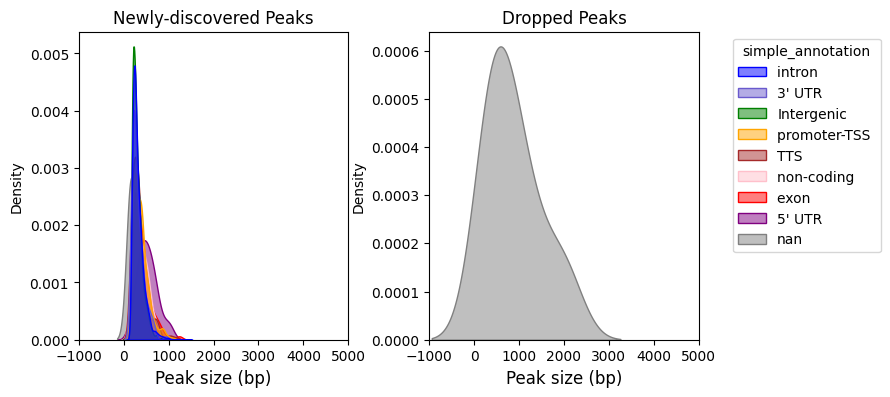

In [9]:
color_map = {'intron ': 'blue', 'promoter-TSS ': 'orange', 'Intergenic': 'green', 'exon ': 'red',
                "5' UTR ": 'purple', 'TTS ': 'brown', 'non-coding ': 'pink', "3' UTR ": 'slateblue', 'nan': 'grey'}
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

sns.kdeplot(data=newly_discovered_peaks_annot, x='peak_size', hue='simple_annotation', fill=True, ax=ax[0], 
            common_norm=False, alpha=0.5, palette=color_map)
sns.kdeplot(data=lost_peaks_annot, x='peak_size', hue='simple_annotation', fill=True, ax=ax[1], 
            common_norm=False, alpha=0.5, palette=color_map)

ax[0].set_xlabel('Peak size (bp)', fontsize=12)
ax[0].set_title('Newly-discovered Peaks', fontsize=12)
ax[1].set_xlabel('Peak size (bp)', fontsize=12)
ax[1].set_title('Dropped Peaks', fontsize=12)

for a in ax:
    a.set_xlim(-1000, 5000)

ax[1].legend_.remove()
sns.move_legend(ax[0], "upper right", bbox_to_anchor=(3, 1))

fig.subplots_adjust(wspace=0.3)

-------------- 	 Raw peaks , FRIP peaks , Newly-discovered peaks , Dropped peaks
Median peak size: ['526.0         ', '515.0         ', '280.0         ', '787.0         ']
Mean peak size: [np.float64(694.4691759793687), np.float64(704.4337708228168), np.float64(320.1877459984256), np.float64(871.1428571428571)]


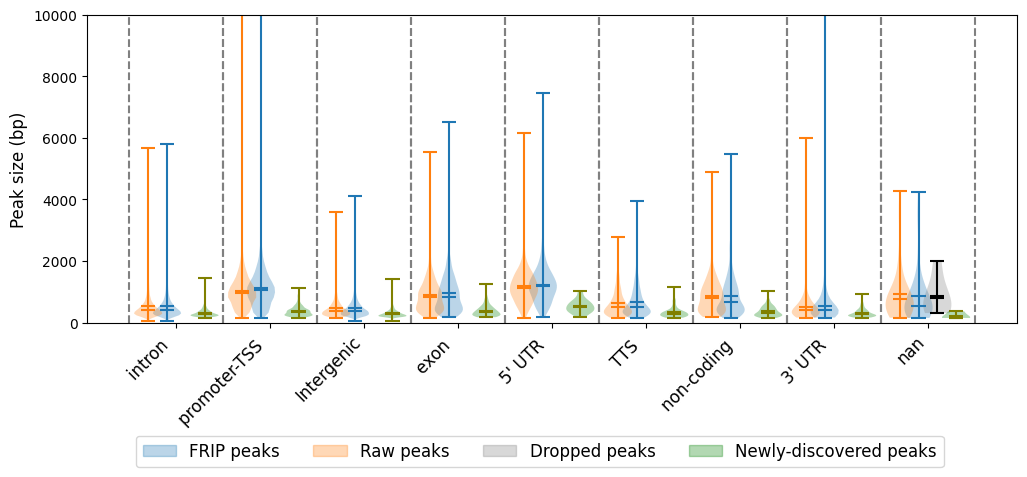

In [19]:
from matplotlib.pylab import size


position_map = {'intron ': 0, 'promoter-TSS ': 1, 'Intergenic': 2, 'exon ': 3,
                "5' UTR ": 4, 'TTS ': 5, 'non-coding ': 6, "3' UTR ": 7, 'nan': 8}

position_map_reversed = {v: k for k, v in position_map.items()}


def add_label(violin, label):
    color = violin["bodies"][0].get_facecolor().flatten()
    labels.append((mpatches.Patch(color=color), label))
    

x_positions = range(len(position_map)) 
width = 0.3  # the width of the bars
labels = []

fig, ax = plt.subplots( figsize=(12, 4))

standard_type = raw_peaks_annot['simple_annotation'].unique()
frip_type = frip_peaks_annot['simple_annotation'].unique()
newly_discovered_type = newly_discovered_peaks_annot['simple_annotation'].unique()
lost_type = lost_peaks_annot['simple_annotation'].unique()

standard_peak_size = [ raw_peaks_annot.loc[raw_peaks_annot['simple_annotation'] == genome_type, 'peak_size'] for \
    genome_type in standard_type ]

frip_peak_size = [ frip_peaks_annot.loc[frip_peaks_annot['simple_annotation'] == genome_type, 'peak_size'] for \
    genome_type in frip_type ]
newly_discovered_peak_size = [ newly_discovered_peaks_annot.loc[newly_discovered_peaks_annot['simple_annotation'] == genome_type, 'peak_size'] for \
    genome_type in newly_discovered_type     ]  
lost_peak_size = [ lost_peaks_annot.loc[lost_peaks_annot['simple_annotation'] == genome_type, 'peak_size'] for \
    genome_type in lost_type ]


v2 =ax.violinplot( frip_peak_size, 
              positions=[position_map[genome_type] - 0.1 for genome_type in frip_type], widths=width, vert=True, 
              showmedians=True, showmeans=True,)
add_label(v2, 'FRIP peaks')

v1 = ax.violinplot( standard_peak_size, 
              positions=[position_map[genome_type] - 0.3 for genome_type in standard_type], widths=width, vert=True, 
              showmedians=True, showmeans=True,)
add_label(v1, 'Raw peaks')


v3 = ax.violinplot( lost_peak_size, 
              positions=[position_map[genome_type] + 0.1 for genome_type in lost_type], widths=width, vert=True, 
              showmedians=True, showmeans=True,)
# change color 
for body in v3['bodies']:
    body.set_facecolor( 'grey'   )
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    v3[partname].set_edgecolor('black')
add_label(v3, 'Dropped peaks')


v4 =ax.violinplot( newly_discovered_peak_size, 
              positions=[position_map[genome_type] + 0.3 for genome_type in newly_discovered_type], widths=width, vert=True, 
              showmedians=True, showmeans=True,)
# change color
for body in v4['bodies']:
    body.set_facecolor('green')
for partname in ('cbars','cmins','cmaxes','cmeans','cmedians'):
    v4[partname].set_edgecolor('olive')

add_label(v4, 'Newly-discovered peaks')


## Add vertical line to separate each group
for x in x_positions:
    ax.vlines(x + 0.5 , ymin=0, ymax=20000, colors='grey', linestyles='--')
    ax.vlines(x - 0.5 , ymin=0, ymax=20000, colors='grey', linestyles='--')


ax.set_xticks(x_positions)
ax.set_xticklabels([position_map_reversed[i] for i in x_positions], rotation=45, ha='right', fontsize=12)
ax.set_ylim(0, 10000)
ax.set_ylabel('Peak size (bp)', fontsize=12)
plt.legend(*zip(*labels), loc='upper right', bbox_to_anchor=(0.93, -0.34), ncol=4, fontsize=12)

median_peak_size = [np.median(raw_peaks_annot['peak_size']), np.median(frip_peaks_annot['peak_size']),
                    np.median(newly_discovered_peaks_annot['peak_size']), np.median(lost_peaks_annot['peak_size'])]
mean_peak_size = [np.mean(raw_peaks_annot['peak_size']), np.mean(frip_peaks_annot['peak_size']),
                    np.mean(newly_discovered_peaks_annot['peak_size']), np.mean(lost_peaks_annot['peak_size'])]
print(f'-------------- \t Raw peaks , FRIP peaks , Newly-discovered peaks , Dropped peaks')
print(f'Median peak size: {[str(size) + "         " for size in median_peak_size]}') # show with 4 decimal places
print(f'Mean peak size: {mean_peak_size}')




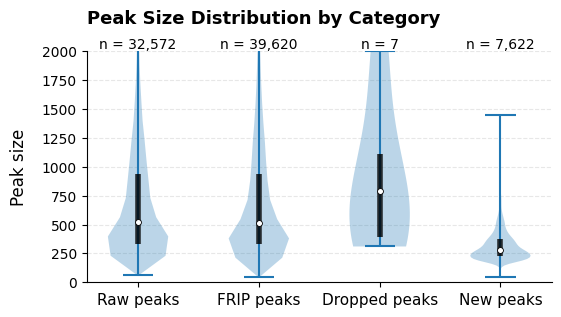

In [20]:
fig, ax = plt.subplots( nrows=1, ncols=1, figsize=(6,3))
width = 0.5

peaks_size = [
                raw_peaks_annot['peak_size'],
                frip_peaks_annot['peak_size'],
                lost_peaks_annot['peak_size'],
                newly_discovered_peaks_annot['peak_size'],
]
x_positions = range(len(peaks_size))
labels = ['Raw peaks', 'FRIP peaks', 'Dropped peaks', 'New peaks']

v = ax.violinplot( peaks_size, positions=x_positions, widths=width, vert=True)




for i, body in enumerate(v['bodies']):

    body.set_alpha(0.3)
    body.set_zorder(2)
    
    # Calculate stats for the "Inner Boxplot"
    data = peaks_size[i]
    q1, median, q3 = np.percentile(data, [25, 50, 75])
    mean_val = np.mean(data)

    # Draw thick line for the IQR
    ax.vlines(i, q1, q3, color='black', lw=4, alpha=0.8)
    # Draw the Median as a white dot
    ax.scatter(i, median, color='white', s=18, zorder=4, edgecolor='black', lw=0.6)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.3, zorder=0)

ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Peak size', fontsize=12, labelpad=10)
ax.set_title('Peak Size Distribution by Category', fontsize=13, fontweight='bold', loc='left', pad=20)
ax.set_ylim(0, 2000)

n_peaks = [len(a) for a in peaks_size]
for i, n in zip(x_positions, n_peaks):
    ax.text(i, ax.get_ylim()[1]*1.01, f'n = {n:,}', ha='center', fontsize=10)


# Check cCRE annotations

In [12]:
cCRE_subdir=os.path.join(FRIPpeaks_vs_Rawpeaks_dir, 'cCRE_annotation')
cCRE_newly_discovered_peaks_file = os.path.join(cCRE_subdir, 'cCRE_annot_newly_discovered_peaks.bed')
cCRE_lost_peaks_file = os.path.join(cCRE_subdir, 'cCRE_annot_lost_peaks.bed')

cCRE_newly_discovered_peaks = pd.read_csv(cCRE_newly_discovered_peaks_file, sep='\t', header=None)
cCRE_lost_peaks = pd.read_csv(cCRE_lost_peaks_file, sep='\t', header=None)

columns = ['chrom', 'chromStart', 'chromEnd', 'name', 'peak_auc_score', 'strand', 'signalValue', 'pValue', 'qValue', 'peak', 
           'cCREs_chrom', 'cCREs_start', 'cCREs_end', 'cCREs_an1', 'cCREs_an2', 'encode_label', 'overlap_bp']

cCRE_lost_peaks.columns = columns
cCRE_newly_discovered_peaks.columns = columns

cCRE_lost_peaks.shape, cCRE_newly_discovered_peaks.shape,

((7, 17), (9737, 17))

In [13]:
# total lost peaks that cover CREs 
len(cCRE_lost_peaks.loc[cCRE_lost_peaks['overlap_bp'] > 0 ]['name'].unique()) 

0

In [14]:
# Total CREs newly-discovered peaks cover
cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['overlap_bp'] > 0 ].shape  # total cCREs are covered 


(9611, 17)

In [15]:
# total newly-discovered peaks that cover CREs 
len(cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['overlap_bp'] > 0 ]['name'].unique()) 

7496

# Vis cCREs

In [16]:
cCRE_newly_discovered_peaks['peak_size'] = cCRE_newly_discovered_peaks['chromEnd'] - cCRE_newly_discovered_peaks['chromStart']
cCRE_newly_discovered_peaks['cCREs_size'] = cCRE_newly_discovered_peaks['cCREs_end'] - cCRE_newly_discovered_peaks['cCREs_start']
cCRE_newly_discovered_peaks['overlap_cCREs'] = cCRE_newly_discovered_peaks['overlap_bp'] > 0 



cCRE_lost_peaks['peak_size'] = cCRE_lost_peaks['chromEnd'] - cCRE_lost_peaks['chromStart']
cCRE_lost_peaks['cCREs_size'] = cCRE_lost_peaks['cCREs_end'] - cCRE_lost_peaks['cCREs_start']
cCRE_lost_peaks['overlap_cCREs'] = cCRE_lost_peaks['overlap_bp'] > 0 



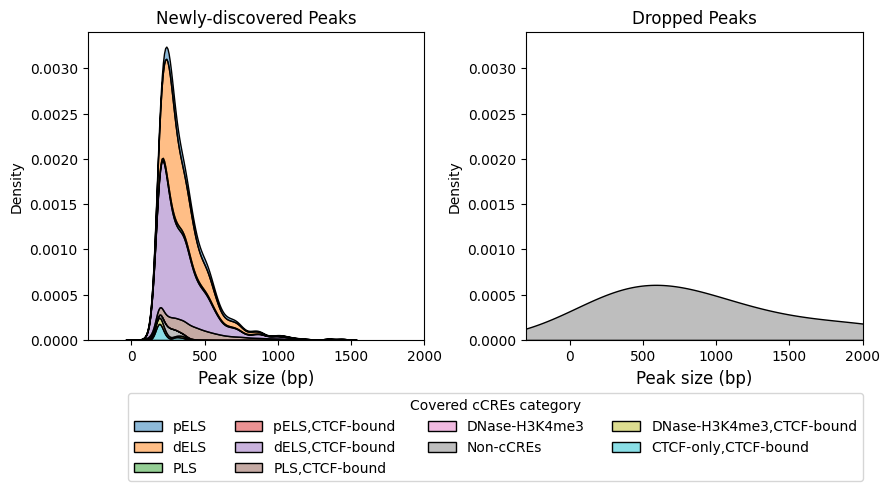

In [17]:
cCRE_newly_discovered_peaks['covered_cCREs_category'] = cCRE_newly_discovered_peaks['encode_label'] 
cCRE_newly_discovered_peaks.loc[cCRE_newly_discovered_peaks['encode_label'] == '.', 'covered_cCREs_category'] = 'Non-cCREs'

cCRE_lost_peaks['covered_cCREs_category'] = cCRE_lost_peaks['encode_label']
cCRE_lost_peaks.loc[cCRE_lost_peaks['encode_label'] == '.', 'covered_cCREs_category'] = 'Non-cCREs'

hue_color = ['pELS', 'dELS', 'PLS', 
             'pELS,CTCF-bound ',  'dELS,CTCF-bound', "PLS,CTCF-bound", 
             'DNase-H3K4me3', 'Non-cCREs',  "DNase-H3K4me3,CTCF-bound", 'CTCF-only,CTCF-bound',]
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

g0 = sns.kdeplot(data=cCRE_newly_discovered_peaks, x='peak_size', hue='covered_cCREs_category', fill=True, ax=ax[0], 
            common_norm=True, alpha=0.5, hue_order=hue_color, multiple='stack')
g1 = sns.kdeplot(data=cCRE_lost_peaks, x='peak_size', hue='covered_cCREs_category', fill=True, ax=ax[1], 
            common_norm=True, alpha=0.5, hue_order=hue_color, multiple='stack')

ax[0].set_xlabel('Peak size (bp)', fontsize=12)
ax[0].set_title('Newly-discovered Peaks', fontsize=12)
ax[1].set_xlabel('Peak size (bp)', fontsize=12)
ax[1].set_title('Dropped Peaks', fontsize=12)

ax[0].set_xlim(-300, 2000)
ax[1].set_xlim(-300, 2000)
ax[0].set_xticks(np.arange(0, 2001, 500))
ax[1].set_xticks(np.arange(0, 2001, 500))
ax[0].set_ylim(0, ax[0].get_ylim()[1])
ax[1].set_ylim(0, ax[0].get_ylim()[1])
ax[0].set_yticks(np.arange(0, ax[0].get_ylim()[1], 0.0005))
ax[1].set_yticks(np.arange(0, ax[0].get_ylim()[1] , 0.0005))


ax[1].legend_.remove()
sns.move_legend(ax[0], "upper left", bbox_to_anchor=(0.1, -.15), title='Covered cCREs category', fontsize=10, ncol=4)


fig.subplots_adjust(wspace=0.3)

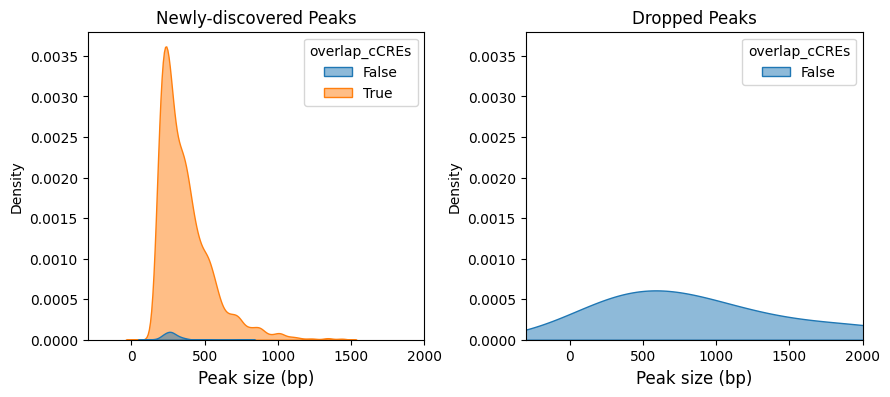

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

g0 = sns.kdeplot(data=cCRE_newly_discovered_peaks, x='peak_size', hue='overlap_cCREs', fill=True, ax=ax[0], 
            common_norm=True, alpha=0.5, color=['green', 'grey'])
g1 = sns.kdeplot(data=cCRE_lost_peaks, x='peak_size', hue='overlap_cCREs', fill=True, ax=ax[1], 
            common_norm=True, alpha=0.5, color=['green', 'grey'])

ax[0].set_xlabel('Peak size (bp)', fontsize=12)
ax[0].set_title('Newly-discovered Peaks', fontsize=12)
ax[1].set_xlabel('Peak size (bp)', fontsize=12)
ax[1].set_title('Dropped Peaks', fontsize=12)

ax[0].set_xlim(-300, 2000)
ax[1].set_xlim(-300, 2000)
ax[0].set_xticks(np.arange(0, 2001, 500))
ax[1].set_xticks(np.arange(0, 2001, 500))
ax[0].set_ylim(0, ax[0].get_ylim()[1])
ax[1].set_ylim(0, ax[0].get_ylim()[1])
ax[0].set_yticks(np.arange(0, ax[0].get_ylim()[1], 0.0005))
ax[1].set_yticks(np.arange(0, ax[0].get_ylim()[1] , 0.0005))


fig.subplots_adjust(wspace=0.3)